In [3]:
import pandas as pd
import numpy as np

diabetes = pd.read_csv(r"C:\Users\anaku\Documents\prism tasks\diabetes_dataset\Healthcare-Diabetes.csv")
df = pd.DataFrame(diabetes)
print(df.head())

   Id  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0   1            6      148             72             35        0  33.6   
1   2            1       85             66             29        0  26.6   
2   3            8      183             64              0        0  23.3   
3   4            1       89             66             23       94  28.1   
4   5            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [4]:
df = df.drop(columns=['Id'])
df.describe().round(1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.0,2768.0,2768.0,2768.0,2768.0,2768.0,2768.0,2768.0,2768.0
mean,3.7,121.1,69.1,20.8,80.1,32.1,0.5,33.1,0.3
std,3.3,32.0,19.2,16.1,112.3,8.1,0.3,11.8,0.5
min,0.0,0.0,0.0,0.0,0.0,0.0,0.1,21.0,0.0
25%,1.0,99.0,62.0,0.0,0.0,27.3,0.2,24.0,0.0
50%,3.0,117.0,72.0,23.0,37.0,32.2,0.4,29.0,0.0
75%,6.0,141.0,80.0,32.0,130.0,36.6,0.6,40.0,1.0
max,17.0,199.0,122.0,110.0,846.0,80.6,2.4,81.0,1.0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2768 non-null   int64  
 1   Glucose                   2768 non-null   int64  
 2   BloodPressure             2768 non-null   int64  
 3   SkinThickness             2768 non-null   int64  
 4   Insulin                   2768 non-null   int64  
 5   BMI                       2768 non-null   float64
 6   DiabetesPedigreeFunction  2768 non-null   float64
 7   Age                       2768 non-null   int64  
 8   Outcome                   2768 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 194.8 KB


In [6]:
# replace biologically impossible zeros with NaN
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [7]:
print(df.isna().sum())

Pregnancies                    0
Glucose                       18
BloodPressure                125
SkinThickness                800
Insulin                     1330
BMI                           39
DiabetesPedigreeFunction       0
Age                            0
Outcome                        0
dtype: int64


Imputation

In [8]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].fillna(df[cols_with_zero].median())
print(df.isna().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


# Descriptive analytics

In [9]:
df['Outcome'].value_counts(normalize=True).round(2)

Outcome
0    0.66
1    0.34
Name: proportion, dtype: float64

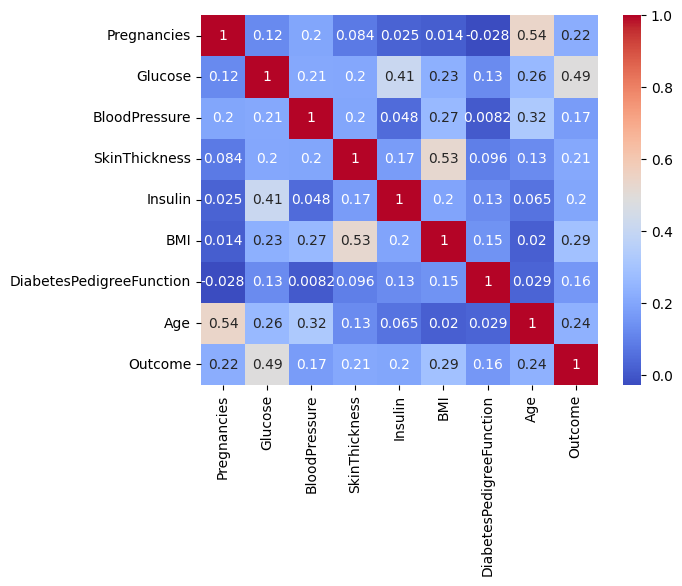

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

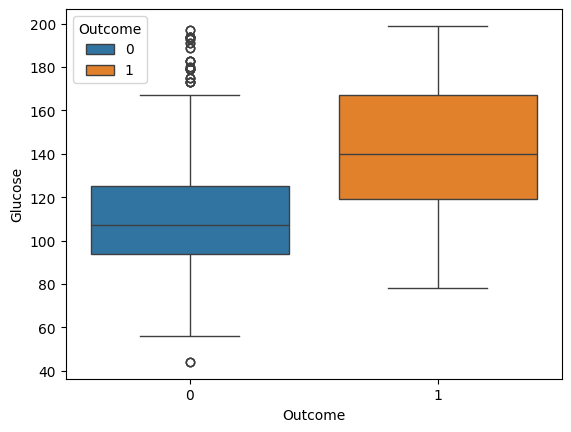

In [11]:
sns.boxplot(x='Outcome', y='Glucose', data=df, hue='Outcome')
plt.show()

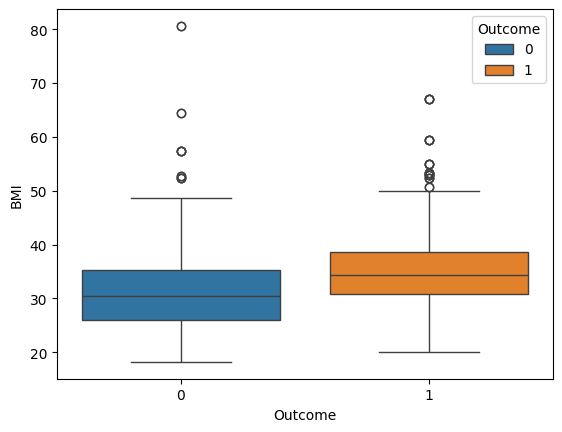

In [12]:
sns.boxplot(x='Outcome', y='BMI', data=df, hue='Outcome')
plt.show()

# Predictive analytics

### Preparing the data for modelling

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training the model

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### Evaluating model performance

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nPrecision:', precision_score(y_test, y_pred))   # how many predicted diabetics are actually diabetic
print('\nRecall:', recall_score(y_test, y_pred))         # how many actual diabetics were correctly identified
print('\nF1 Score:', f1_score(y_test, y_pred))           
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))   # true negatives, false positives, false negatives, true positives
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.7527075812274369

Precision: 0.6776315789473685

Recall: 0.5392670157068062

F1 Score: 0.6005830903790087

Confusion Matrix:
 [[314  49]
 [ 88 103]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82       363
           1       0.68      0.54      0.60       191

    accuracy                           0.75       554
   macro avg       0.73      0.70      0.71       554
weighted avg       0.75      0.75      0.74       554



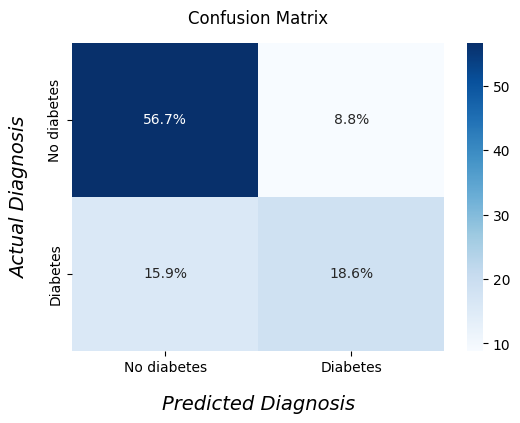

In [45]:
cm = confusion_matrix(y_test, y_pred)

# convert to percentages

cm_percent = cm / np.sum(cm) * 100

# create labels with % symbol
labels = np.array([[f"{value:.1f}%" for value in row] for row in cm_percent])

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_percent, 
    annot=labels,
    fmt='',
    cmap='Blues',
    xticklabels=['No diabetes', 'Diabetes'],
    yticklabels=['No diabetes', 'Diabetes']
)
 
plt.xlabel('Predicted Diagnosis', labelpad=14, fontsize=14, fontstyle='oblique')
plt.ylabel('Actual Diagnosis', labelpad=14, fontsize=14, fontstyle='oblique')
plt.title('Confusion Matrix', pad=14)
plt.show()

### Feature importance

In [ ]:
coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coeffs)

                    Feature  Coefficient
1                   Glucose     1.153065
5                       BMI     0.503098
0               Pregnancies     0.435140
6  DiabetesPedigreeFunction     0.215571
7                       Age     0.094446
3             SkinThickness     0.076644
2             BloodPressure    -0.020733
4                   Insulin    -0.092146


C:\Users\anaku\AppData\Local\Temp\ipykernel_33168\3879514387.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coeffs, palette='rocket')


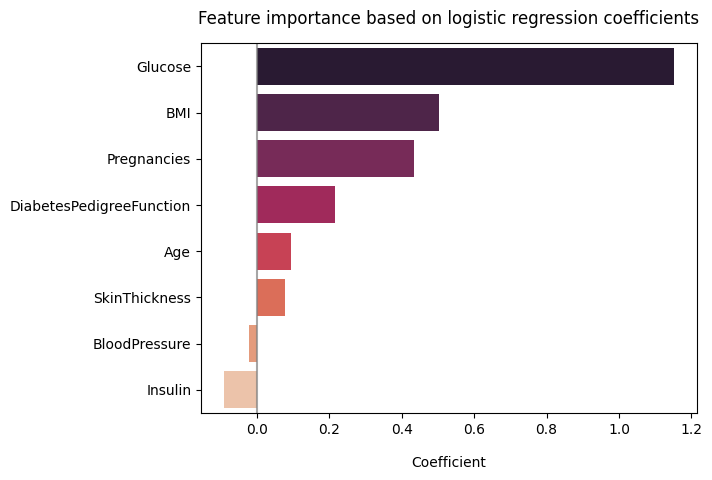

In [32]:
sns.barplot(x='Coefficient', y='Feature', data=coeffs, palette='rocket')
plt.title('Feature importance based on logistic regression coefficients', pad=14)
plt.xlabel('Coefficient', labelpad=14)
plt.ylabel(None)
plt.axvline(0, color='grey', alpha=0.7)